In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import lightgbm as lgb
import xgboost as xgb

# Step 1: Load the dataset
file_path = "cardio_train.csv"  # Update with your file's path
data = pd.read_csv(file_path, delimiter=";")

# Step 2: Data preprocessing
# Drop the 'id' column as it is not a feature
data = data.drop(columns=['id'])

# Split features and target
X = data.drop(columns=['cardio'])
y = data['cardio']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train LightGBM model
lgbm_params = {
    'objective': 'binary',
    'metric': 'binary_error',
    'boosting_type': 'gbdt',
    'learning_rate': 0.1,
    'num_leaves': 31,
    'max_depth': -1,
    'verbose': -1
}

lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_test = lgb.Dataset(X_test, label=y_test, reference=lgb_train)

lgb_model = lgb.train(
    lgbm_params,
    lgb_train,
    valid_sets=[lgb_train, lgb_test],
    num_boost_round=1000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

# Step 4: Train XGBoost model
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    learning_rate=0.1,
    max_depth=6,
    n_estimators=500,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Step 5: Ensemble the models
# Get predictions from both models
lgb_predictions = lgb_model.predict(X_test)
xgb_predictions = xgb_model.predict_proba(X_test)[:, 1]  # Probabilities for class 1

# Average the predictions
ensemble_predictions = (lgb_predictions + xgb_predictions) / 2
ensemble_binary_predictions = (ensemble_predictions > 0.5).astype(int)

# Step 6: Evaluate the ensemble model
accuracy = accuracy_score(y_test, ensemble_binary_predictions)
precision = precision_score(y_test, ensemble_binary_predictions)
recall = recall_score(y_test, ensemble_binary_predictions)
f1 = f1_score(y_test, ensemble_binary_predictions)
classification_report_result = classification_report(y_test, ensemble_binary_predictions)

print("Ensemble Model Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:\n", classification_report_result)


Training until validation scores don't improve for 50 rounds
[100]	training's binary_error: 0.251196	valid_1's binary_error: 0.258643
Early stopping, best iteration is:
[69]	training's binary_error: 0.254643	valid_1's binary_error: 0.257714
Ensemble Model Evaluation:
Accuracy: 0.7384
Precision: 0.7591
Recall: 0.6997
F1 Score: 0.7282

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.78      0.75      6988
           1       0.76      0.70      0.73      7012

    accuracy                           0.74     14000
   macro avg       0.74      0.74      0.74     14000
weighted avg       0.74      0.74      0.74     14000



### Here's how you can ensemble the LightGBM and XGBoost models for cardiovascular prediction by averaging their predictions:

## Steps to Ensemble:
#### Train the LightGBM model.
#### Train the XGBoost model.
#### Average their predictions on the test dataset to get the final ensemble prediction.
#### Evaluate the ensemble model.

### Import Libraries

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import lightgbm as lgb
import xgboost as xgb

### Load and Preprocess Data

In [6]:
# Load the dataset
file_path = "cardio_train.csv"  # Update with your file's path
data = pd.read_csv(file_path, delimiter=";")

# Drop the 'id' column as it is not a feature
data = data.drop(columns=['id'])

# Split features and target
X = data.drop(columns=['cardio'])
y = data['cardio']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Train LightGBM Model

In [7]:
# Define LightGBM parameters
lgbm_params = {
    'objective': 'binary',
    'metric': 'binary_error',
    'boosting_type': 'gbdt',
    'learning_rate': 0.1,
    'num_leaves': 31,
    'max_depth': -1,
    'verbose': -1
}

# Create LightGBM datasets
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_test = lgb.Dataset(X_test, label=y_test, reference=lgb_train)

# Train LightGBM model
lgb_model = lgb.train(
    lgbm_params,
    lgb_train,
    valid_sets=[lgb_train, lgb_test],
    num_boost_round=1000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

Training until validation scores don't improve for 50 rounds
[100]	training's binary_error: 0.251196	valid_1's binary_error: 0.258643
Early stopping, best iteration is:
[69]	training's binary_error: 0.254643	valid_1's binary_error: 0.257714


### Train XGBoost Model

In [8]:
# Train XGBoost model
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    learning_rate=0.1,
    max_depth=6,
    n_estimators=500,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

### Ensemble Predictions

In [9]:
# Get predictions from LightGBM
lgb_predictions = lgb_model.predict(X_test)

# Get predictions from XGBoost (probabilities for class 1)
xgb_predictions = xgb_model.predict_proba(X_test)[:, 1]

# Average the predictions
ensemble_predictions = (lgb_predictions + xgb_predictions) / 2
ensemble_binary_predictions = (ensemble_predictions > 0.5).astype(int)

### Evaluate the Ensemble Model

In [10]:
# Evaluate the ensemble model
accuracy = accuracy_score(y_test, ensemble_binary_predictions)
precision = precision_score(y_test, ensemble_binary_predictions)
recall = recall_score(y_test, ensemble_binary_predictions)
f1 = f1_score(y_test, ensemble_binary_predictions)
classification_report_result = classification_report(y_test, ensemble_binary_predictions)

print("Ensemble Model Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:\n", classification_report_result)

Ensemble Model Evaluation:
Accuracy: 0.7384
Precision: 0.7591
Recall: 0.6997
F1 Score: 0.7282

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.78      0.75      6988
           1       0.76      0.70      0.73      7012

    accuracy                           0.74     14000
   macro avg       0.74      0.74      0.74     14000
weighted avg       0.74      0.74      0.74     14000



### Plot Feature Importance

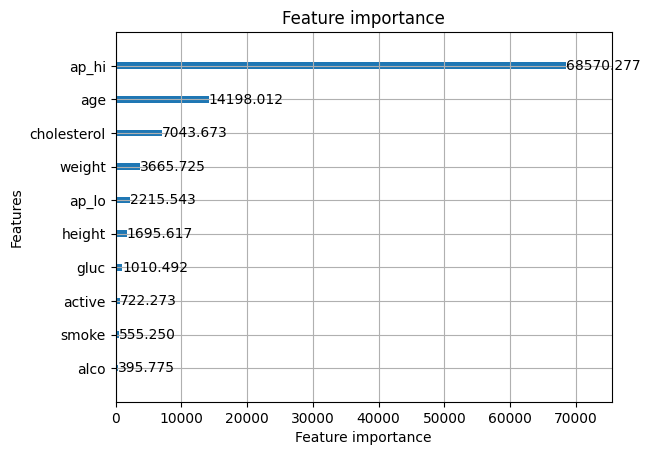

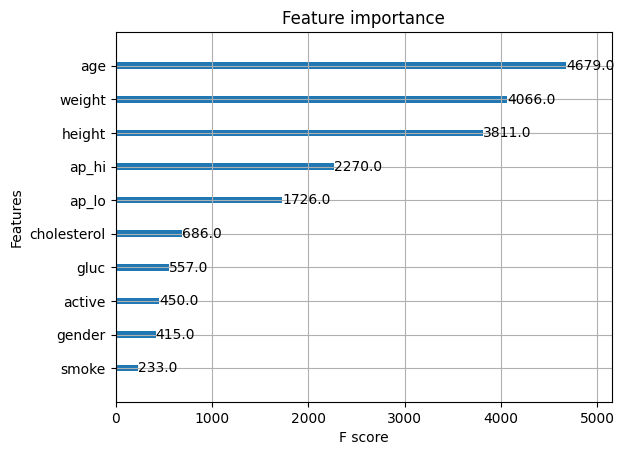

In [11]:
import matplotlib.pyplot as plt

# Plot feature importance for LightGBM
lgb.plot_importance(lgb_model, max_num_features=10, importance_type='gain')
plt.show()

# (Optional) Feature importance for XGBoost
xgb.plot_importance(xgb_model, max_num_features=10)
plt.show()

### Saving the Ensemble Model

In [12]:
import joblib

# Save the ensemble predictions (if needed) or individual models
joblib.dump(lgb_model, "lightgbm_model.pkl")  # Save LightGBM model
joblib.dump(xgb_model, "xgboost_model.pkl")   # Save XGBoost model

# Optional: Save the ensemble logic as a custom function
def ensemble_predict(X):
    lgb_preds = lgb_model.predict(X)
    xgb_preds = xgb_model.predict_proba(X)[:, 1]
    return (lgb_preds + xgb_preds) / 2

joblib.dump(ensemble_predict, "ensemble_model.pkl")  # Save the ensemble logic


['ensemble_model.pkl']

In [13]:
# Load LightGBM and XGBoost models
lgb_model_loaded = joblib.load("lightgbm_model.pkl")
xgb_model_loaded = joblib.load("xgboost_model.pkl")

# Load the ensemble logic
ensemble_predict_loaded = joblib.load("ensemble_model.pkl")

# Example: Predict using the loaded ensemble model
ensemble_predictions_loaded = ensemble_predict_loaded(X_test)
ensemble_binary_predictions_loaded = (ensemble_predictions_loaded > 0.5).astype(int)
